In [4]:
import pandas as pd
import matplotlib.pyplot as plt


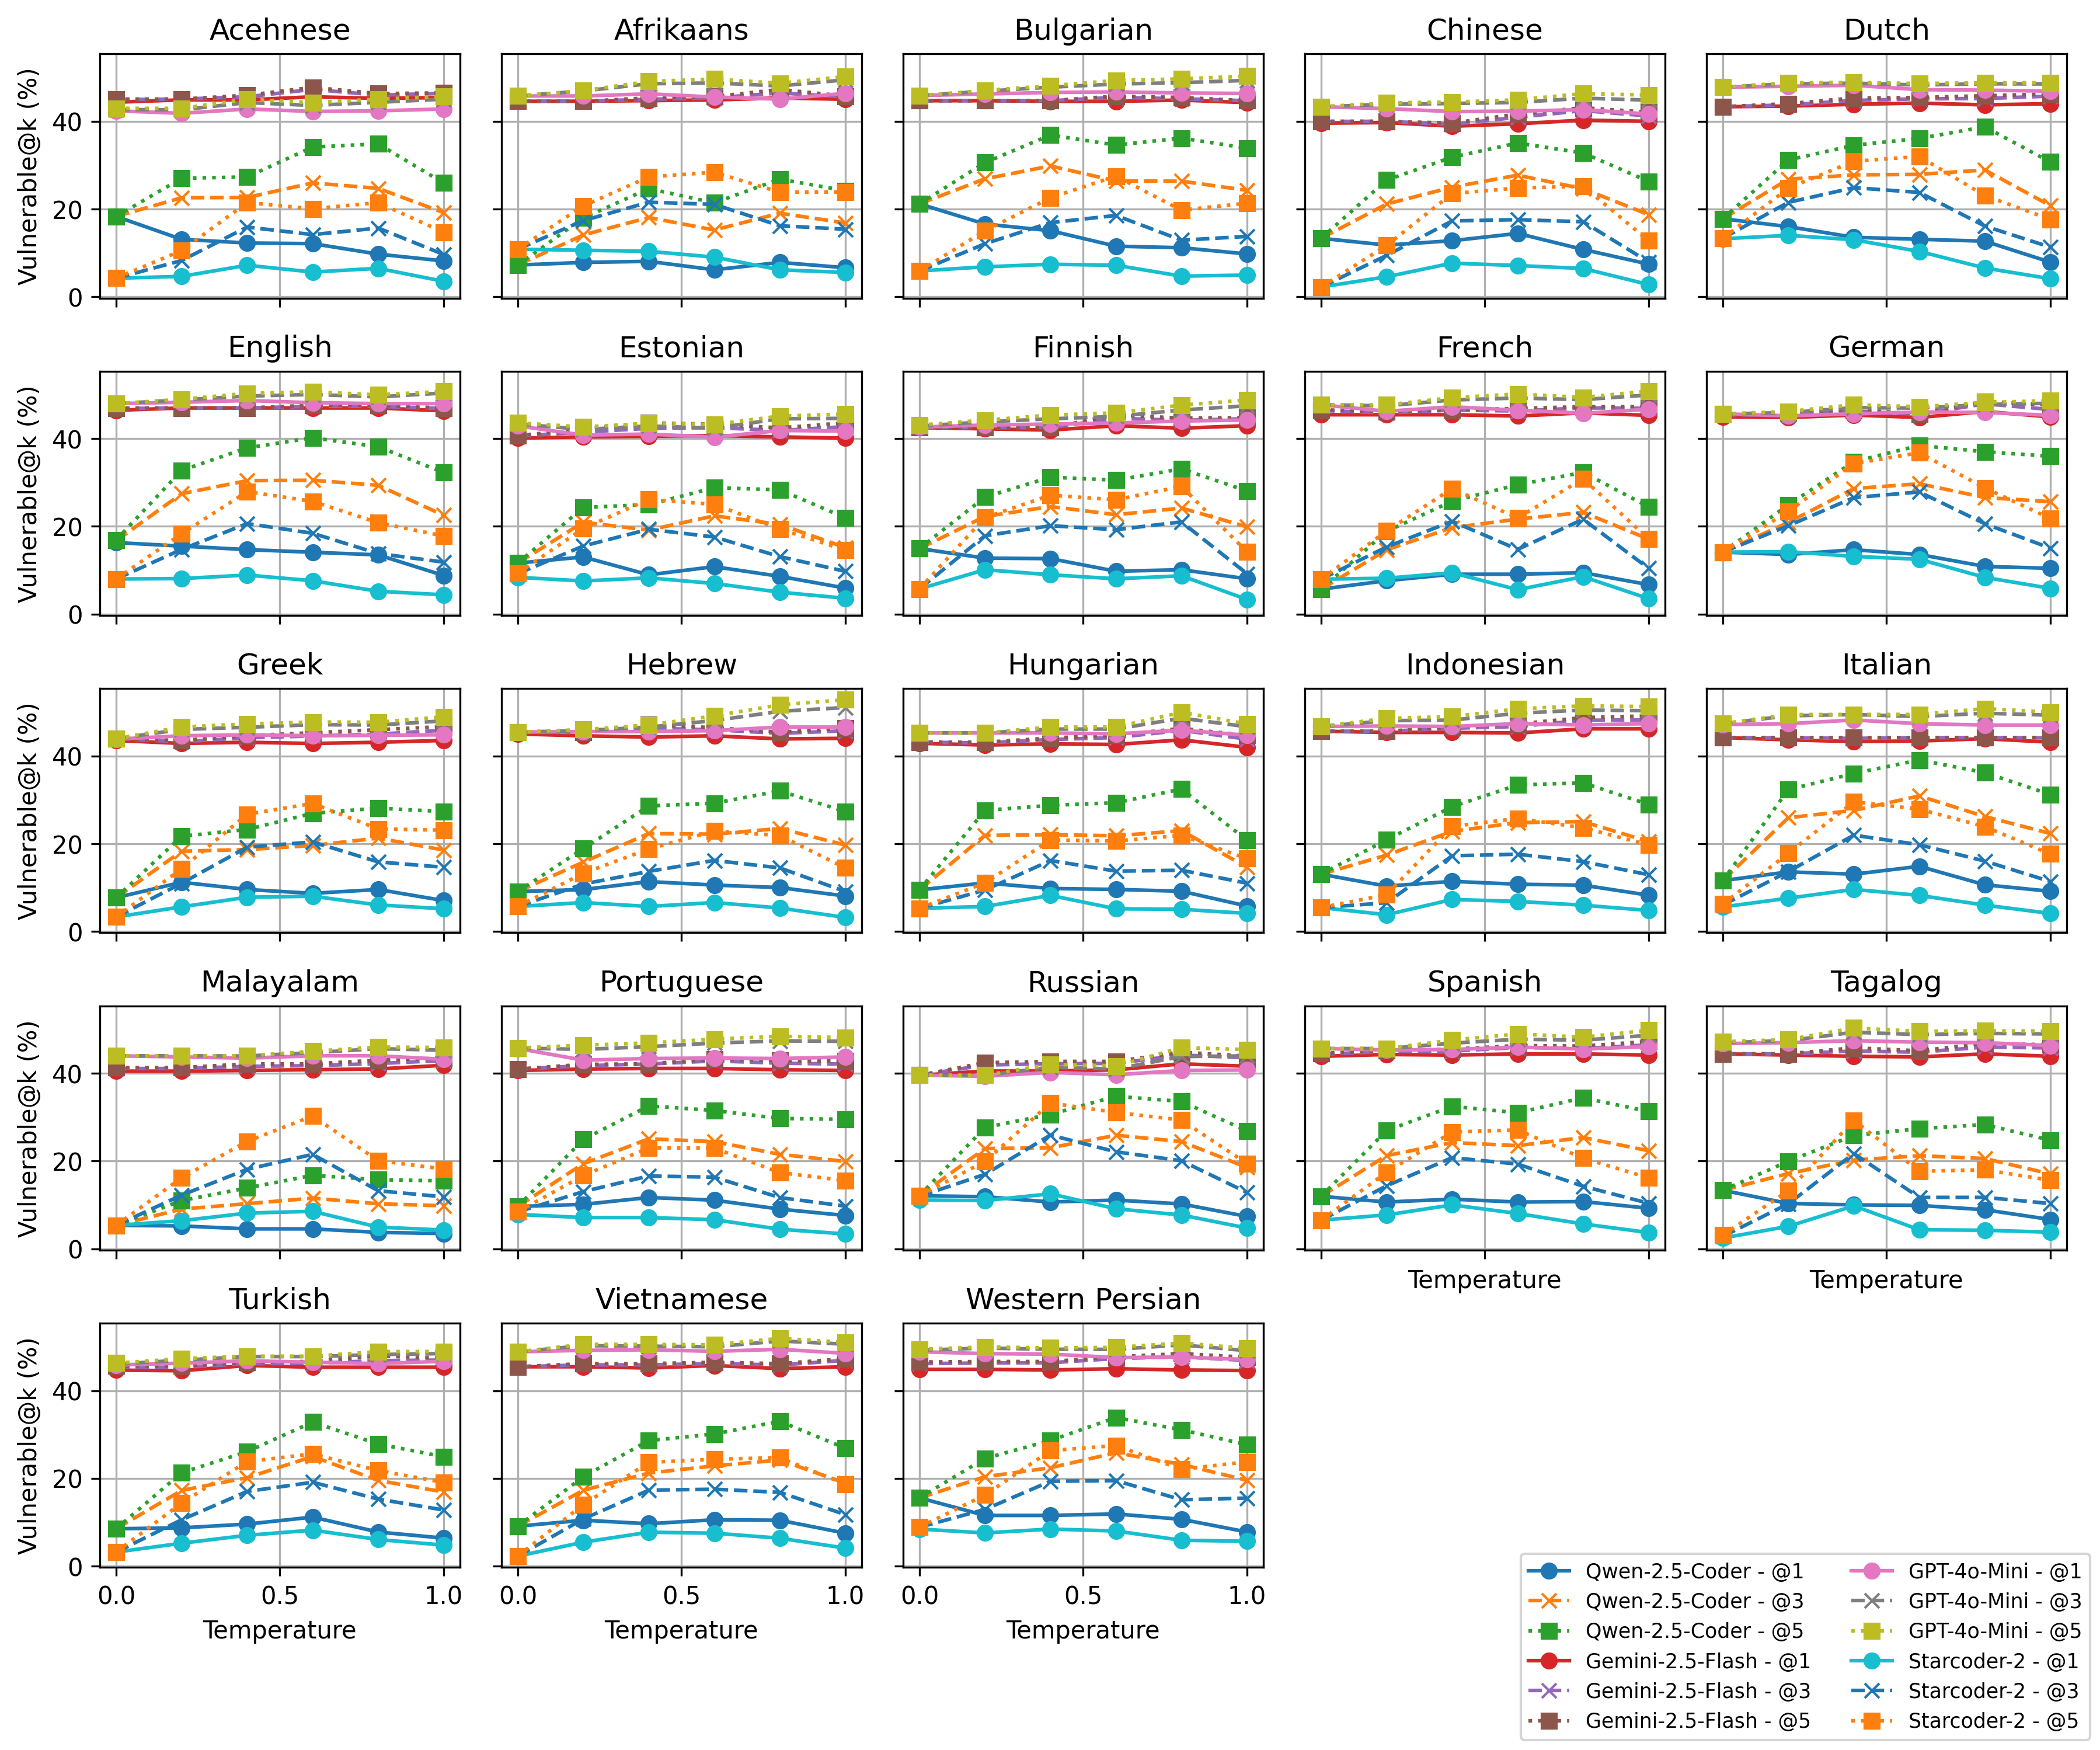

In [5]:
# Load data into a DataFrame
# Since the input is too large to handle manually here, we will simulate a smaller representative sample for demonstration


df = pd.read_csv("../Evaluation/CodeQL_Results-Multi.csv")
# Sort the DataFrame by Model, Temp, and Language
df = df.sort_values(by=['Model', 'Temp', 'Language'])
df['Temp'] = df['Temp'].astype(float)

languages = df['Language'].unique()
num_languages = len(languages)

# Determine the layout of subplots
cols = 5
rows = (num_languages + cols - 1) // cols

fig_vul, axs = plt.subplots(rows, cols, figsize=(12, 2 * rows), sharex=True, sharey=True, dpi=300)
axs_vul = axs.flatten()

for idx, lang in enumerate(languages):
    ax = axs_vul[idx]
    subset = df[df['Language'] == lang]
    for model in subset['Model'].unique():
        model_data = subset[subset['Model'] == model]
        if "gpt" in model:
            model = "GPT-4o-Mini"
        if "gemini" in model:
            model = "Gemini-2.5-Flash"
        if "Qwen" in model:
            model = "Qwen-2.5-Coder"
        if "starcoder" in model:
            model = "Starcoder-2"
        ax.plot(model_data['Temp'], model_data['vul@1'], label=f'{model} - @1', linestyle='-', marker='o')
        ax.plot(model_data['Temp'], model_data['vul@3'], label=f'{model} - @3', linestyle='--', marker='x')
        ax.plot(model_data['Temp'], model_data['vul@5'], label=f'{model} - @5', linestyle=':', marker='s')
    ax.set_title(lang)
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Vulnerable@k (%)')
    if idx % cols != 0:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)

    if idx < (rows - 1) * cols and (idx != 18 and idx != 19):
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)
    ax.grid(True)
    ax.grid(True)

# Remove unused axes
for j in range(idx + 1, len(axs_vul)):
    fig_vul.delaxes(axs_vul[j])

handles, labels = axs_vul[0].get_legend_handles_labels()
fig_vul.legend(handles, labels, loc='lower right',ncol=2, fontsize='small')

plt.tight_layout()
fig_vul.subplots_adjust(bottom=0.1)
plt.savefig('./Figure/vul_at_k_comparison.png', dpi=300)



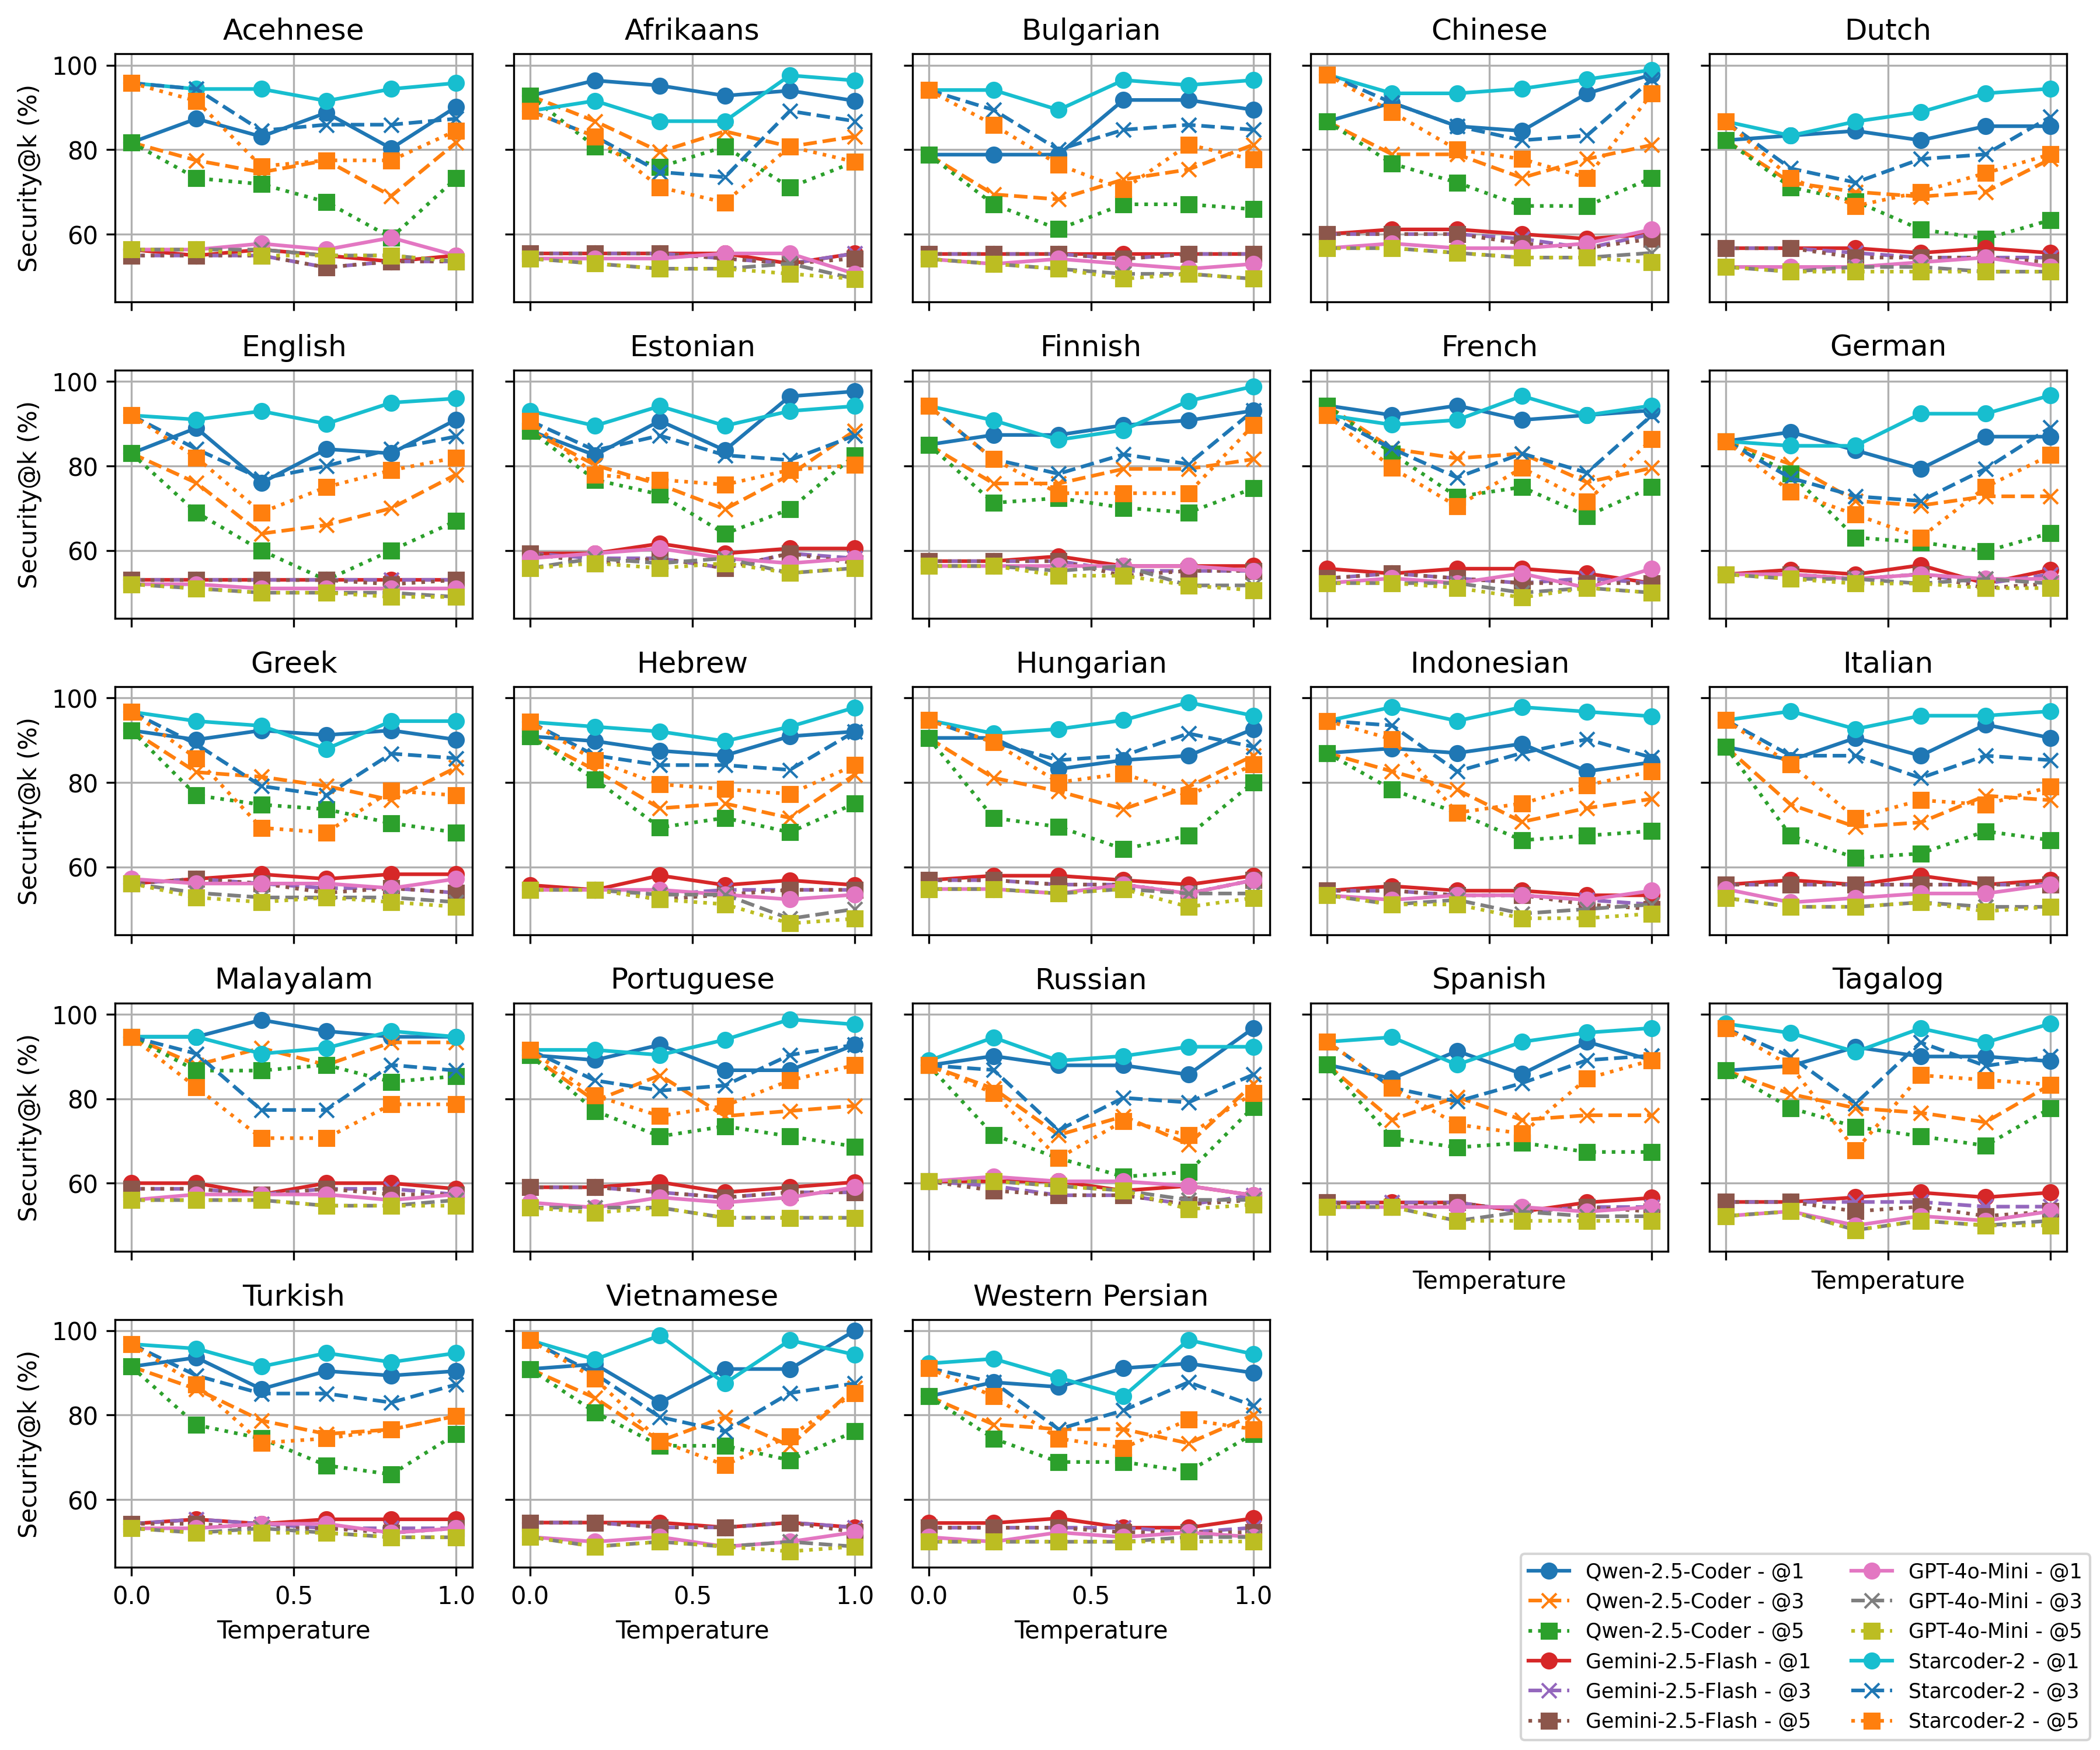

In [6]:

# Determine the layout of subplots
cols = 5
rows = (num_languages + cols - 1) // cols

fig_vul, axs = plt.subplots(rows, cols, figsize=(12, 2 * rows), sharex=True, sharey=True, dpi=300)
axs_vul = axs.flatten()

for idx, lang in enumerate(languages):
    ax = axs_vul[idx]
    subset = df[df['Language'] == lang]
    for model in subset['Model'].unique():
        model_data = subset[subset['Model'] == model]
        if "gpt" in model:
            model = "GPT-4o-Mini"
        if "gemini" in model:
            model = "Gemini-2.5-Flash"
        if "Qwen" in model:
            model = "Qwen-2.5-Coder"
        if "starcoder" in model:
            model = "Starcoder-2"
        ax.plot(model_data['Temp'], model_data['security@1'], label=f'{model} - @1', linestyle='-', marker='o')
        ax.plot(model_data['Temp'], model_data['security@3'], label=f'{model} - @3', linestyle='--', marker='x')
        ax.plot(model_data['Temp'], model_data['security@5'], label=f'{model} - @5', linestyle=':', marker='s')

    
    ax.set_title(lang)
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Security@k (%)')

    if idx % cols != 0:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)

    if idx < (rows - 1) * cols and (idx != 18 and idx != 19):
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)
    ax.grid(True)

# Remove unused axes
for j in range(idx + 1, len(axs_vul)):
    fig_vul.delaxes(axs_vul[j])

handles, labels = axs_vul[0].get_legend_handles_labels()
fig_vul.legend(handles, labels, loc='lower right',ncol=2, fontsize='small')

plt.tight_layout()
fig_vul.subplots_adjust(bottom=0.1)
plt.savefig('./Figure/security_at_k_comparison.png', dpi=300)
